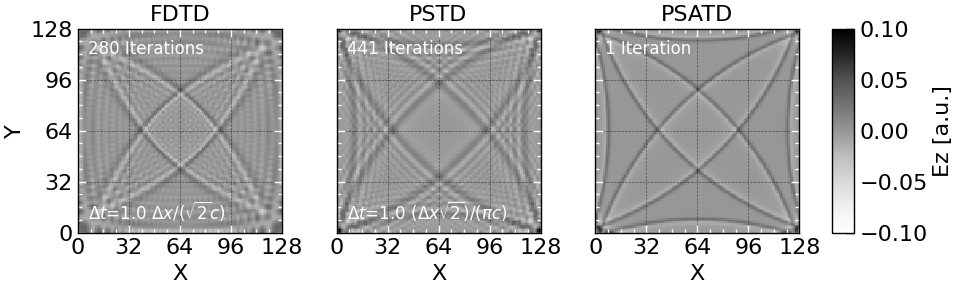

No such comm: 8860f1f5271f4e23aeb0333393698217


In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftfreq
import scienceplots
plt.style.use(['science', 'nature', 'notebook', 'grid', 'high-vis'])
%matplotlib ipympl

# 1. 增加分辨率和传播时间，让误差积累
N = 128
dx = dy = 1.0
c = 1.0
T = 200

dt_fdtd = 1 / np.sqrt(2) * dx / c  # 降低 dt 确保 PSTD 稳定
dt_pstd = np.sqrt(2) / np.pi * dx / c
dt_psatd = T

# dt_fdtd *= 1e-1
# dt_pstd *= 1e-1

# K 空间设置
kx = 2 * np.pi * fftfreq(N, d=dx)
ky = 2 * np.pi * fftfreq(N, d=dy)
kx_grid, ky_grid = np.meshgrid(kx, ky, indexing='ij')
k2 = kx_grid**2 + ky_grid**2
k = np.sqrt(k2)
k[0,0] = 1e-12

# 初始化场
fields = {
    'FDTD':   {'Ez': np.zeros((N,N)), 'Hx': np.zeros((N,N)), 'Hy': np.zeros((N,N))},
    'PSTD':  {'Ez': np.zeros((N,N)), 'Hx': np.zeros((N,N)), 'Hy': np.zeros((N,N))},
    'PSATD': {'Ez': np.zeros((N,N)), 'Hx': np.zeros((N,N)), 'Hy': np.zeros((N,N))}
}

SAMPLE_RATE = 1 / (7 * dt_pstd)
fields_sampled = {
    'FDTD':   {'Ez': np.zeros((int(T * SAMPLE_RATE + 1), N,N))},
    'PSTD':  {'Ez': np.zeros((int(T * SAMPLE_RATE + 1), N,N))},
    'PSATD': {'Ez': np.zeros((int(T * SAMPLE_RATE + 1), N,N))}
}

# 初始波源：稍微平滑一点的高斯波，减少 PSTD 的谱截断震荡
x0, y0 = N//2, N//2
X, Y = np.ogrid[:N, :N]
r_sq = (X-x0)**2 + (Y-y0)**2
init_ez = np.exp(-r_sq / (2 * 1**2))

for key in fields:
    fields[key]['Ez'][:] = init_ez

# 2. 演化循环
t = 0.0
f = fields['FDTD']

for i in range(int(T // dt_fdtd) + 1):
    # --- Yee (空间 2 阶, 时间 2 阶) ---
    fields_sampled['FDTD']['Ez'][int(t * SAMPLE_RATE)] = f['Ez'].copy()
    f['Hx'] -= 0.5 * dt_fdtd * (np.roll(f['Ez'], -1, axis=1) - f['Ez']) / dy
    f['Hy'] += 0.5 * dt_fdtd * (np.roll(f['Ez'], -1, axis=0) - f['Ez']) / dx
    f['Ez'] += dt_fdtd * ((f['Hy'] - np.roll(f['Hy'], 1, axis=0))/dx - (f['Hx'] - np.roll(f['Hx'], 1, axis=1))/dy)
    f['Hx'] -= 0.5 * dt_fdtd * (np.roll(f['Ez'], -1, axis=1) - f['Ez']) / dy
    f['Hy'] += 0.5 * dt_fdtd * (np.roll(f['Ez'], -1, axis=0) - f['Ez']) / dx
    t += dt_fdtd

t = 0.0
f = fields['PSTD']
for i in range(int(T // dt_pstd) + 1):
    # --- PSTD (空间谱精度, 时间 2 阶) ---
    fields_sampled['PSTD']['Ez'][int(t * SAMPLE_RATE)] = f['Ez'].copy()
    Ez_k = fft2(f['Ez'])
    # 空间导数在 K 空间完成，时间依然是 Leapfrog 差分
    f['Hx'] -= dt_pstd * np.real(ifft2(1j * ky_grid * Ez_k)) 
    f['Hy'] += dt_pstd * np.real(ifft2(1j * kx_grid * Ez_k)) 
    Hx_k, Hy_k = fft2(f['Hx']), fft2(f['Hy'])
    f['Ez'] += dt_pstd * np.real(ifft2(1j * kx_grid * Hy_k - 1j * ky_grid * Hx_k))
    t += dt_pstd

t = 0.0
f = fields['PSATD']
for i in range(int(T // dt_pstd) + 1):
    # --- PSATD (空间谱精度, 时间解析) ---
    fields_sampled['PSATD']['Ez'][int(t * SAMPLE_RATE)] = f['Ez'].copy()
    # Ez_k, Hx_k, Hy_k = fft2(f['Ez']), fft2(f['Hx']), fft2(f['Hy'])
    Ez_k, Hx_k, Hy_k = fft2(init_ez), fft2(np.zeros((N, N))), fft2(np.zeros((N, N)))
    C, S = np.cos(c*k*t), np.sin(c*k*t)/k
    Ez_k_n = C * Ez_k + 1j * c * S * (kx_grid * Hy_k - ky_grid * Hx_k)
    Hx_k_n = C * Hx_k - 1j * (S/c) * (ky_grid * Ez_k)
    Hy_k_n = C * Hy_k + 1j * (S/c) * (kx_grid * Ez_k)
    f['Ez'], f['Hx'], f['Hy'] = np.real(ifft2(Ez_k_n)), np.real(ifft2(Hx_k_n)), np.real(ifft2(Hy_k_n))
    t += dt_pstd

plt.close()
plt.clf()
plt.cla()
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharex=True, sharey=True, gridspec_kw = {'wspace': 0.15, 'hspace': 0.05, 'bottom': 0.2, 'right': 0.8})

for i in range(3):
    axes[i].label_outer()
    axes[i].set_aspect('equal')
    axes[i].xaxis.set_major_locator(plt.MultipleLocator(32))
    axes[i].yaxis.set_major_locator(plt.MultipleLocator(32))
    axes[i].autoscale(True)
    axes[i].set_xlabel('X')
    axes[i].tick_params(color = 'w', which = 'both', axis = 'both')

axes[0].set_ylabel('Y')
vmax = 1e-1
pc1 = axes[0].pcolormesh(init_ez, cmap='Greys', vmax = vmax, vmin = -vmax, zorder = -1)
pc2 = axes[1].pcolormesh(init_ez, cmap='Greys', vmax = vmax, vmin = -vmax, zorder = -1)
pc3 = axes[2].pcolormesh(init_ez, cmap='Greys', vmax = vmax, vmin = -vmax, zorder = -1)
cax = fig.add_axes([axes[2].get_position().x1 + 0.03, axes[2].get_position().y0, 0.02, axes[2].get_position().height])
plt.colorbar(pc3, cax=cax, label='Ez [a.u.]')

axes[0].set_title('FDTD')
axes[1].set_title('PSTD')
axes[2].set_title('PSATD')

ref_r = 0 * c
circle1 = axes[0].add_artist(plt.Circle((x0, y0), ref_r, color='C0', fill=False, linestyle='--', lw=1.5, alpha=0.6))
circle2 = axes[1].add_artist(plt.Circle((x0, y0), ref_r, color='C0', fill=False, linestyle='--', lw=1.5, alpha=0.6))
circle3 = axes[2].add_artist(plt.Circle((x0, y0), ref_r, color='C0', fill=False, linestyle='--', lw=1.5, alpha=0.6))

text1 = axes[0].text(0.05, 0.95, f"{0} Iteration", transform=axes[0].transAxes, fontsize=12, color = 'w', fontweight='normal', va='top')
text2 = axes[1].text(0.05, 0.95, f"{0} Iteration", transform=axes[1].transAxes, fontsize=12, color = 'w', fontweight='normal', va='top')
text3 = axes[2].text(0.05, 0.95, f"{1} Iteration", transform=axes[2].transAxes, fontsize=12, color = 'w', fontweight='normal', va='top')

axes[0].text(0.05, 0.05, r"$\Delta t$=" + f"{dt_fdtd / dx * np.sqrt(2) * c:.1f} " + r"$\Delta x/(\sqrt{2}c)$", transform=axes[0].transAxes, fontsize=12, color = 'w', fontweight='normal', va='bottom')
axes[1].text(0.05, 0.05, r"$\Delta t$=" + f"{dt_pstd / dx * np.pi / np.sqrt(2) * c:.1f} " + r"$(\Delta x \sqrt{2}) / (\pi c)$", transform=axes[1].transAxes, fontsize=12, color = 'w', fontweight='normal', va='bottom')
# axes[0].text(0.05, 0.05, f"[dt = {dt_fdtd / (dx**2 / (4 * alpha)):.1f}" + r"$\Delta x^2/4\alpha$]", transform=axes[0].transAxes, fontsize=12, color = 'w', fontweight='normal', va='bottom')

def update(i):
    # 这里我们直接显示最终结果，因为 FDTD 和 PSATD 的演化已经在上面完成了
    pc1.set_array(fields_sampled['FDTD']['Ez'][i].ravel())
    pc2.set_array(fields_sampled['PSTD']['Ez'][i].ravel())
    pc3.set_array(fields_sampled['PSATD']['Ez'][i].ravel())
    text1.set_text(f"{int(i / SAMPLE_RATE / dt_fdtd)} Iterations")
    text2.set_text(f"{int(i / SAMPLE_RATE / dt_pstd)} Iterations")    
    circle1.set_radius((i + 1) / SAMPLE_RATE * c)
    circle2.set_radius((i + 1) / SAMPLE_RATE * c)
    circle3.set_radius((i + 1) / SAMPLE_RATE * c)
    
import matplotlib.animation

ani = matplotlib.animation.FuncAnimation(fig, update, frames=np.arange(np.shape(fields_sampled['FDTD']['Ez'])[0]), repeat=True, interval=30, blit = True, repeat_delay = 1000)

ani.save('Figure/unit_pulse.gif', writer='pillow', fps=10)
plt.show()


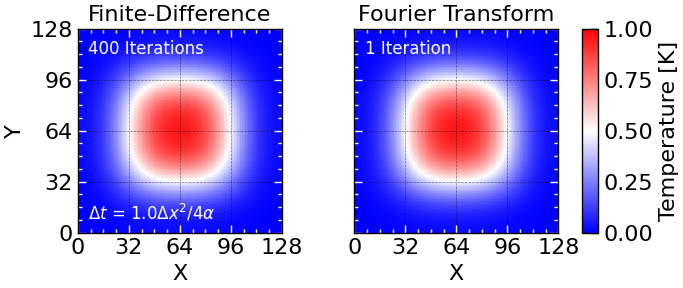

In [120]:
import matplotlib
import matplotlib.animation
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftfreq
import scienceplots
plt.style.use(['science', 'nature', 'notebook', 'grid', 'high-vis'])
%matplotlib ipympl


N = 128
dx = dy = 1.0
alpha = 1.0  # 热扩散系数
    
# 稳定性限制：对于 FDTD，dt < dx^2 / (4 * alpha)
# 这里取 0.8，如果设为 1.1，FDTD 将会发散
T = 100.0
dt_fdtd = 1.0 * (dx**2 / (4 * alpha))
dt_psatd = T
    
# K 空间设置
kx = 2 * np.pi * fftfreq(N, d=dx)
ky = 2 * np.pi * fftfreq(N, d=dy)
kx_grid, ky_grid = np.meshgrid(kx, ky, indexing='ij')
k2 = kx_grid**2 + ky_grid**2

# 初始化场 (一个中心热方块)
T_init = np.zeros((N, N)) + 1e-12

T_init[N//4:3*N//4, N//4:3*N//4] = 1.0

T_fdtd = T_init.copy()
T_psatd = T_init.copy()

SAMPLE_RATE = 1 / dt_fdtd
T_fdtd_sampled = np.zeros((int(T * SAMPLE_RATE + 1), N, N))
T_psatd_sampled = np.zeros((int(T * SAMPLE_RATE + 1), N, N))


# 2. 演化循环
for i in range(int(T // dt_fdtd + 1)):
    t = i * dt_fdtd
    # --- A. Yee-like (FTCS 有限差分) ---
    # 使用中心差分计算拉普拉斯算子
    T_fdtd_sampled[i] = T_fdtd.copy()
    laplacian = (np.roll(T_fdtd, 1, axis=0) + np.roll(T_fdtd, -1, axis=0) +
                    np.roll(T_fdtd, 1, axis=1) + np.roll(T_fdtd, -1, axis=1) - 
                    4 * T_fdtd) / dx**2
    T_fdtd += alpha * dt_fdtd * laplacian

    # --- C. PSATD (解析积分/纯谱方法) ---
    # 直接利用热传导方程在 K 空间的解析解
    # 这是绝对稳定的，即使 dt 非常大
    T_psatd_sampled[i] = T_psatd.copy()
    fft_T_psatd = fft2(T_init)
    # T_psatd = np.real(ifft2(fft_T_psatd * np.exp(-alpha * K2 * dt_psatd)))
    T_psatd = np.real(ifft2(fft_T_psatd * np.exp(-alpha * k2 * t)))

plt.close()
plt.clf()
plt.cla()
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=True, gridspec_kw = {'wspace': 0.05, 'hspace': 0.05, 'bottom': 0.2, 'right': 0.8})

for i in range(2):
    axes[i].label_outer()
    axes[i].set_aspect('equal')
    axes[i].xaxis.set_major_locator(plt.MultipleLocator(32))
    axes[i].yaxis.set_major_locator(plt.MultipleLocator(32))
    axes[i].autoscale(True)
    axes[i].set_xlabel('X')
    axes[i].tick_params(color = 'w', which = 'both', axis = 'both')

axes[0].set_ylabel('Y')

axes[0].set_title('Finite-Difference')
axes[1].set_title('Fourier Transform')

pc1 = axes[0].pcolormesh(T_init + np.nan, cmap='bwr', vmax = 1, vmin = 0, zorder = -1)
pc2 = axes[1].pcolormesh(T_init + np.nan, cmap='bwr', vmax = 1, vmin = 0, zorder = -1)
cax = fig.add_axes([axes[1].get_position().x1 + 0.03, axes[1].get_position().y0, 0.02, axes[1].get_position().height])
plt.colorbar(pc2, cax=cax, label='Temperature [K]')

text1 = axes[0].text(0.05, 0.95, f"{0} Iterations", transform=axes[0].transAxes, fontsize=12, color = 'w', fontweight='normal', va='top')
text2 = axes[1].text(0.05, 0.95, f"{1} Iteration", transform=axes[1].transAxes, fontsize=12, color = 'w', fontweight='normal', va='top')

axes[0].text(0.05, 0.05, r"$\Delta t$" + f" = {dt_fdtd / (dx**2 / (4 * alpha)):.1f}" + r"$\Delta x^2/4\alpha$", transform=axes[0].transAxes, fontsize=12, color = 'w', fontweight='normal', va='bottom')

def update(i):
    # 这里我们直接显示最终结果，因为 FDTD 和 PSATD 的演化已经在上面完成了
    pc1.set_array(T_fdtd_sampled[i].ravel())
    pc2.set_array(T_psatd_sampled[i].ravel())
    text1.set_text(f"{i} Iterations")

ani = matplotlib.animation.FuncAnimation(fig, update, frames=np.arange(np.shape(T_fdtd_sampled)[0]), repeat=False, interval=30, blit = True)

ani.save('Figure/heat_diffusion.gif', writer='pillow', fps=30)
plt.show()



In [143]:
T_fdtd_sampled.shape

(120, 128, 128)